# Group Members<br>

### 1. Iman Abadi Bin Mohd Nizwan (A23CS0084) <br>
### 2. Mohamed Alif Fathi Bin Abdul Latif (A23CS0112) <br>
### 3. Muhammad Afiq Danial Bin Rozaidie (A23CS0117) <br>

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [6]:
#Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Rainfall.csv")
df.head()

cols = list(df.columns)
new_cols =list(cols[0].split(','))
new_cols

rain = df[cols[0]].str.split(',', expand=True)
rain.columns = new_cols

print(rain.isnull().sum())

numeric_cols = ['Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']
rain[numeric_cols] = rain[numeric_cols].apply(pd.to_numeric, errors='coerce')

month_order = ['Jan', 'Feb', 'Mar']

rain['Month'] = pd.Categorical(rain['Month'], categories=month_order, ordered=True)

#rain.to_csv('Rainfall_new.csv')

print(rain)
rain.describe()

Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64
  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0  North  2023   Jan  StationA         56.2          9       12.1        2.5   
1  North  2023   Feb  StationA         72.1         12       14.7        3.0   
2  North  2023   Jan  StationB         60.5         10       11.2        1.8   
3  South  2023   Jan  StationC         81.0         13       19.6        7.2   
4  South  2023   Feb  StationC         63.4         11       20.1        7.7   
5   East  2023   Jan  StationD         45.7          8       15.4        5.6   
6   East  2023   Feb  StationD         59.6         10       17.9        6.2   
7   West  2023   Jan  StationE         77.4         12       16.8        4.9   
8   West  2023   Feb  StationE         84.2         13       18.2        5.3   
9  North  2023   Mar  StationB    

,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
count,10.000000,10.00000,10.000000,10.000000
mean,66.160000,10.90000,16.100000,4.740000
std,12.154121,1.66333,2.982542,2.029888
min,45.700000,8.00000,11.200000,1.800000
25%,59.825000,10.00000,14.775000,3.050000
50%,62.450000,11.00000,16.100000,5.100000
75%,76.075000,12.00000,18.125000,6.050000
max,84.200000,13.00000,20.100000,7.700000


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [7]:
#Write your code here

rain_station = rain.groupby('Station')

rain_station.agg({'Rainfall_mm': ['sum'],
                  'RainyDays': ['mean'],
                  'MaxTemp_C': ['mean'],
                  'MinTemp_C': ['mean']})


,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
,sum,mean,mean,mean
Station,,,,
StationA,128.3,10.5,13.40,2.75
StationB,122.0,10.5,13.10,2.50
StationC,144.4,12.0,19.85,7.45
StationD,105.3,9.0,16.65,5.90
StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [8]:
#Write your code here

reg_urbanRural = rain.groupby(['Region','UrbanRural'])
reg_urbanRural.agg({'Rainfall_mm' : 'mean',
                    'MaxTemp_C' : 'mean',
                    'RainyDays' : 'mean'})


Rainfall_mm  MaxTemp_C  RainyDays
Region UrbanRural                                   
East   Rural             52.65      16.65        9.0
North  Rural             61.00      13.10       10.5
       Urban             64.15      13.40       10.5
South  Urban             72.20      19.85       12.0
West   Urban             80.80      17.50       12.5

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [9]:
#Write your code here

month_region = rain.groupby(['Month','Region'])
month_region.agg({'Rainfall_mm' : ['sum', 'mean', 'min', 'max']})

C:\Users\User\AppData\Local\Temp\ipykernel_1424\3213127648.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_region = rain.groupby(['Month','Region'])


Rainfall_mm                   
                     sum   mean   min   max
Month Region                               
Jan   East          45.7  45.70  45.7  45.7
      North        116.7  58.35  56.2  60.5
      South         81.0  81.00  81.0  81.0
      West          77.4  77.40  77.4  77.4
Feb   East          59.6  59.60  59.6  59.6
      North         72.1  72.10  72.1  72.1
      South         63.4  63.40  63.4  63.4
      West          84.2  84.20  84.2  84.2
Mar   East           0.0    NaN   NaN   NaN
      North         61.5  61.50  61.5  61.5
      South          0.0    NaN   NaN   NaN
      West           0.0    NaN   NaN   NaN

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [11]:
#Write your code here

highest = month_region['Rainfall_mm'].max().idxmax()

month, region = highest

print(f"Month with the highest rainfall is in {region} on {month}")


Month with the highest rainfall is in West on Feb


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [ ]:
#Write your code here
year_urbanRural = rain.groupby(['Year','UrbanRural'])
year_urbanRural.agg({'Rainfall_mm' : ['mean', 'min', 'max']}).round(2)


Rainfall_mm            
                       mean   min   max
Year UrbanRural                        
2023 Rural            56.82  45.7  61.5
     Urban            72.38  56.2  84.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [ ]:
#Write your code here
rain['TempRange'] = rain['MaxTemp_C'] - rain['MinTemp_C']
month_region = rain.groupby(['Region','Month'])
month_region['TempRange'].mean()


C:\Users\User\AppData\Local\Temp\ipykernel_5936\2821905047.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_region = rain.groupby(['Region','Month'])


Region  Month
East    Jan       9.8
        Feb      11.7
        Mar       NaN
North   Jan       9.5
        Feb      11.7
        Mar      11.8
South   Jan      12.4
        Feb      12.4
        Mar       NaN
West    Jan      11.9
        Feb      12.9
        Mar       NaN
Name: TempRange, dtype: float64

## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



UrbanRural  Rural  Urban
Region                  
East        105.3    NaN
North       122.0  128.3
South         NaN  144.4
West          NaN  161.6


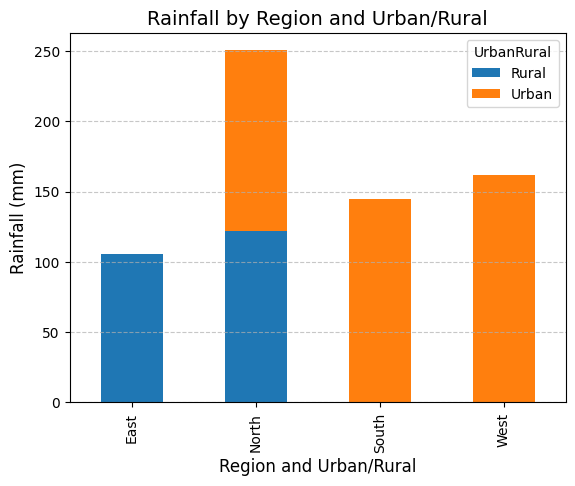

In [ ]:
#Write your code here
total_rain = reg_urbanRural['Rainfall_mm'].sum().unstack()
print(total_rain)

# Create a bar chart
fig, ax = plt.subplots()
total_rain.plot(kind='bar', ax=ax, stacked = True)
plt.title('Rainfall by Region and Urban/Rural', fontsize = 14)
plt.xlabel('Region and Urban/Rural', fontsize = 12)
plt.ylabel('Rainfall (mm)', fontsize = 12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('bar.png')
plt.show()



2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



C:\Users\User\AppData\Local\Temp\ipykernel_5936\1663674445.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_month = rain.groupby(['Month','Station'])['Rainfall_mm']


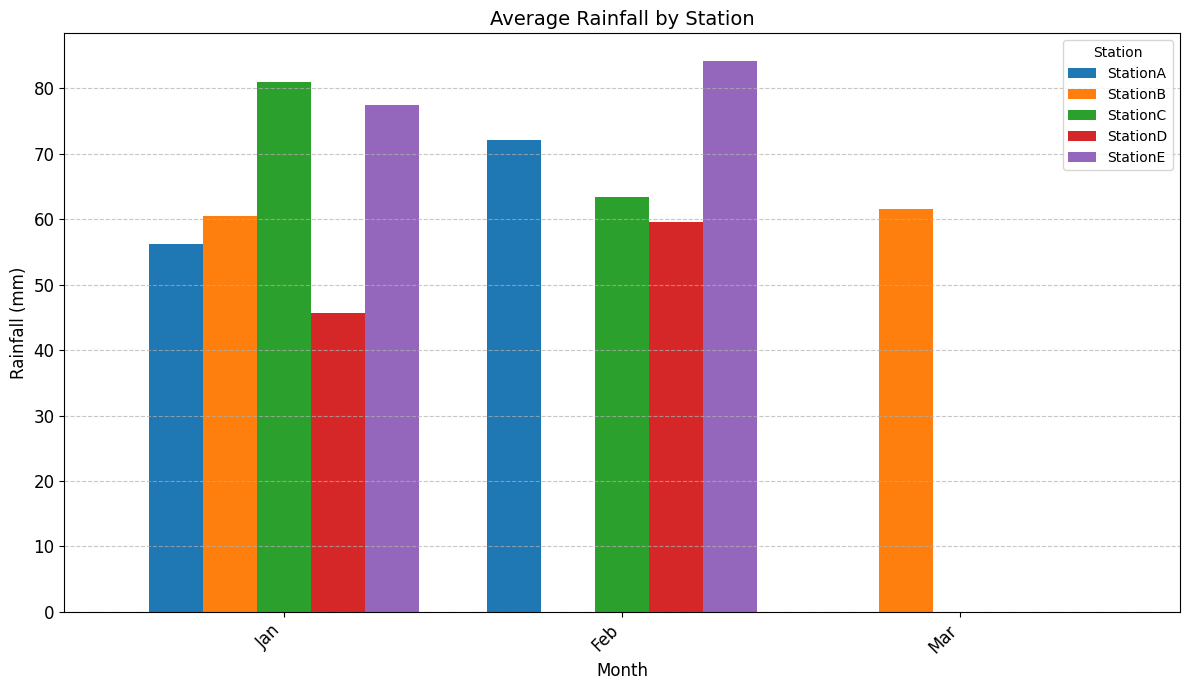

In [ ]:
#Write your code here
station_month = rain.groupby(['Month','Station'])['Rainfall_mm']

fig, ax = plt.subplots(figsize=(12, 7))
station_month.mean().unstack().plot(kind='bar', ax=ax, width=0.8)
plt.title('Average Rainfall by Station', fontsize = 14)
plt.xlabel('Month', fontsize = 12)
plt.ylabel('Rainfall (mm)', fontsize = 12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize = 12)
plt.yticks(fontsize = 12)
plt.tight_layout()
plt.savefig('groupedbar.png')
plt.show()



3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



C:\Users\User\AppData\Local\Temp\ipykernel_5936\3837798711.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_trend = rain.groupby(['Station','Month'])['Rainfall_mm'].mean().unstack()


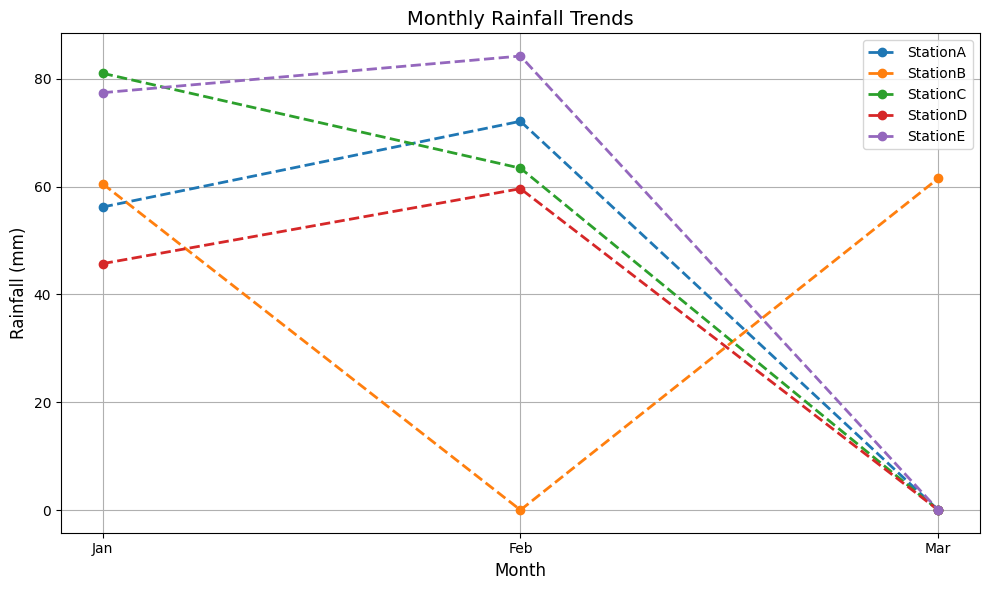

In [ ]:
#Write your code here

rainfall_trend = rain.groupby(['Station','Month'])['Rainfall_mm'].mean().unstack()
rainfall_trend.fillna(0, inplace=True)

station = rainfall_trend.index

# Simple plot
plt.figure(figsize=(10, 6))

# Plot each station
for station in station:
    plt.plot(rainfall_trend.columns, rainfall_trend.loc[station], 
             marker='o', label=station, linewidth=2, linestyle = '--')

plt.xlabel('Month' , fontsize = 12)
plt.ylabel('Rainfall (mm)',fontsize = 12)
plt.title('Monthly Rainfall Trends', fontsize = 14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('line.png')
plt.show()




4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



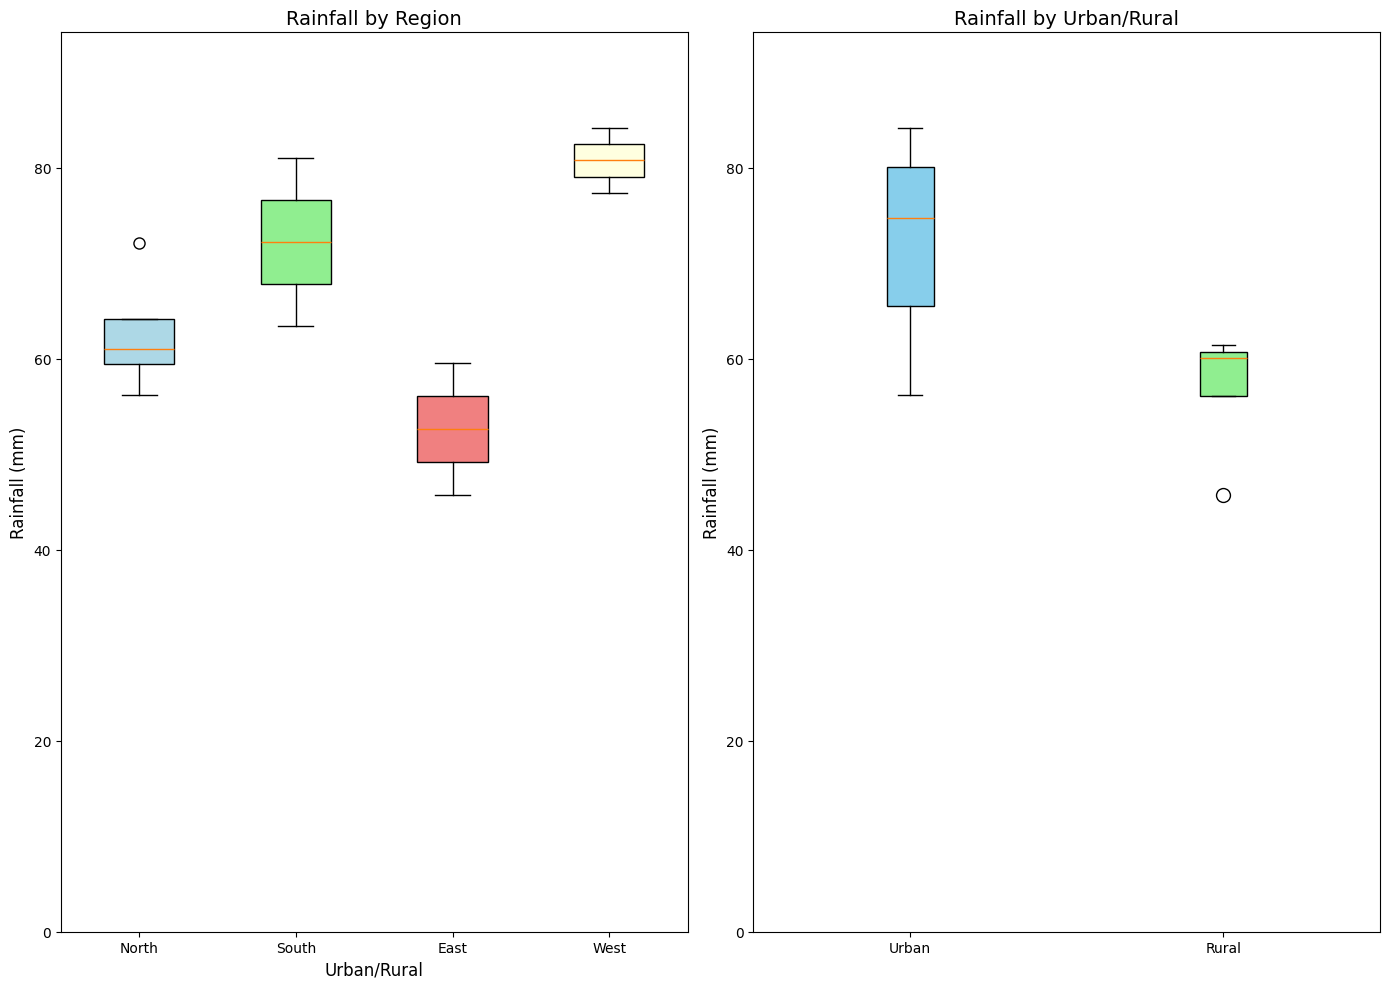

In [ ]:
#Write your code here
# Get unique regions and urban/rural categories
regions = rain['Region'].unique()
urb = rain['UrbanRural'].unique()

# Create two plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 10))

# First plot: Rainfall by Region
box1 = ax[0].boxplot([rain[rain['Region'] == region]["Rainfall_mm"] for region in regions],
                     patch_artist=True)  # This is needed for colors
ax[0].set_xticklabels(regions)
ax[0].set_title('Rainfall by Region', fontsize = 14)
ax[0].set_ylabel('Rainfall (mm)', fontsize = 12)
ax[0].set_xlabel('Region', fontsize = 12)
ax[0].set_ylim(0, rain['Rainfall_mm'].max()+10)

# Add custom colors to boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for box, color in zip(box1['boxes'], colors):
    box.set_facecolor(color)

# Make outliers red and bigger
for outlier in box1['fliers']:
    outlier.set_color('red')
    outlier.set_markersize(8)

# Second plot: Rainfall by Urban/Rural
box2 = ax[1].boxplot([rain[rain['UrbanRural'] == u]["Rainfall_mm"] for u in urb],
                     patch_artist=True)  # This is needed for colors
ax[1].set_xticklabels(urb)
ax[1].set_title('Rainfall by Urban/Rural', fontsize = 14)
ax[1].set_ylabel('Rainfall (mm)', fontsize = 12)
ax[0].set_xlabel('Urban/Rural', fontsize = 12)
ax[1].set_ylim(0, rain['Rainfall_mm'].max()+10)

# Add custom colors to boxes
colors2 = ['skyblue', 'lightgreen']
for box, color in zip(box2['boxes'], colors2):
    box.set_facecolor(color)

# Make outliers red and bigger
for outlier in box2['fliers']:
    outlier.set_color('blue')
    outlier.set_markersize(10)

plt.tight_layout()
plt.savefig('boxplot.png')
plt.show()


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



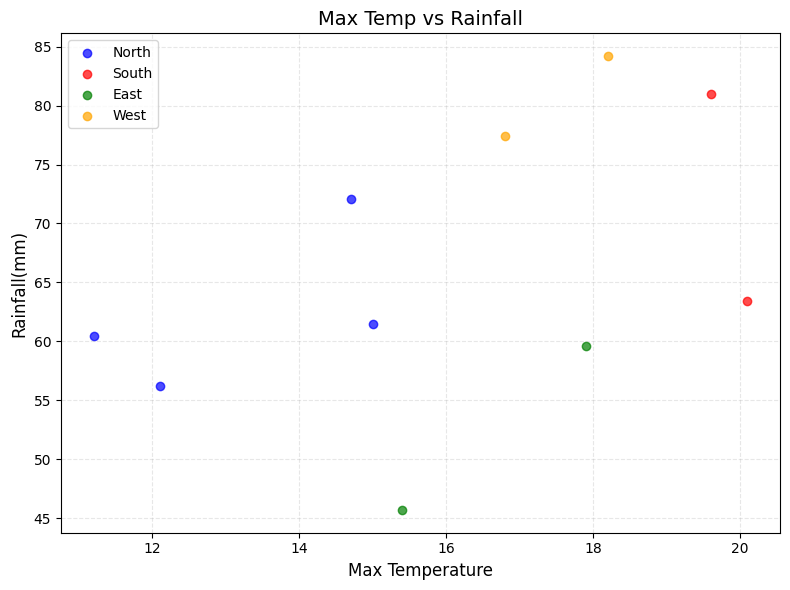

In [ ]:
#Write your code here

fig, ax = plt.subplots(figsize=(8, 6))

# Get unique regions for color mapping
regions = rain['Region'].unique()
colors = ['blue', 'red', 'green', 'orange']

# Plot each region with different color
for i, region in enumerate(regions):
    region_data = rain[rain['Region'] == region]
    ax.scatter(region_data['MaxTemp_C'], region_data['Rainfall_mm'], 
               c=colors[i], label=region, alpha=0.7)

# Customize plot
ax.set_title("Max Temp vs Rainfall", fontsize=14)
ax.set_xlabel("Max Temperature", fontsize=12)
ax.set_ylabel("Rainfall(mm)", fontsize=12)
ax.grid(linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('scatter.png')
plt.show()

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



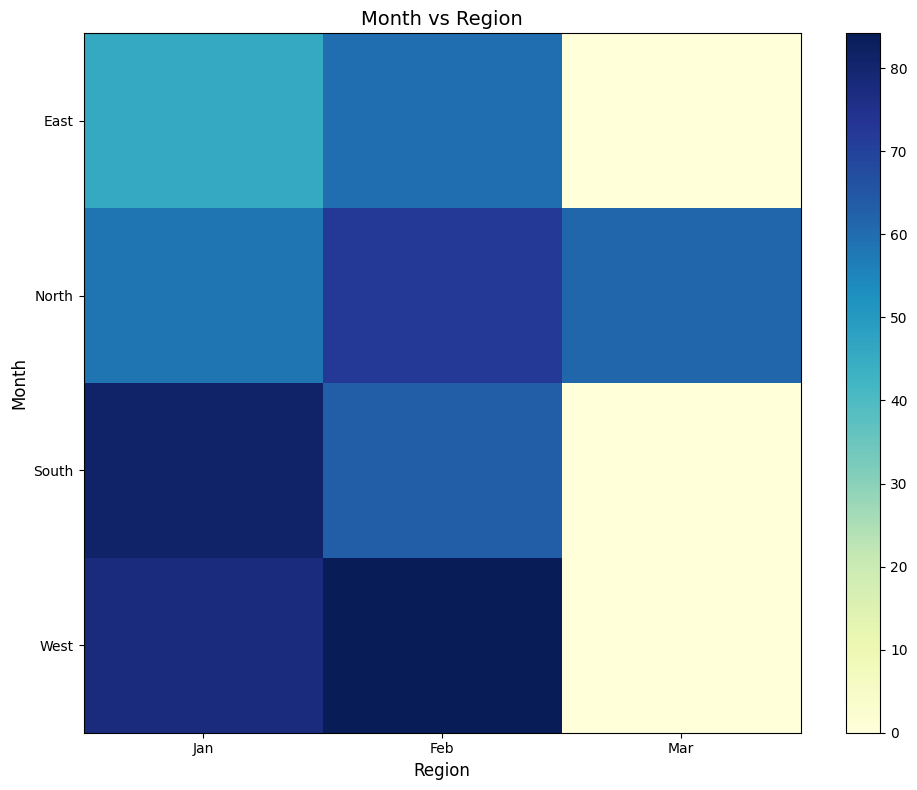

In [ ]:
#Write your code here

avg_month_region = month_region['Rainfall_mm'].mean()
avg_month_region.fillna(0, inplace=True)

heatmap_data = avg_month_region.unstack()

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')

# Set ticks and labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Customize plot
cbar = plt.colorbar(im, ax=ax)
ax.set_title("Month vs Region", fontsize=14)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Month", fontsize=12)

plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()



7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [ ]:
#Write your code here

# All the code are written at all the plots before according to this question's requirements


## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


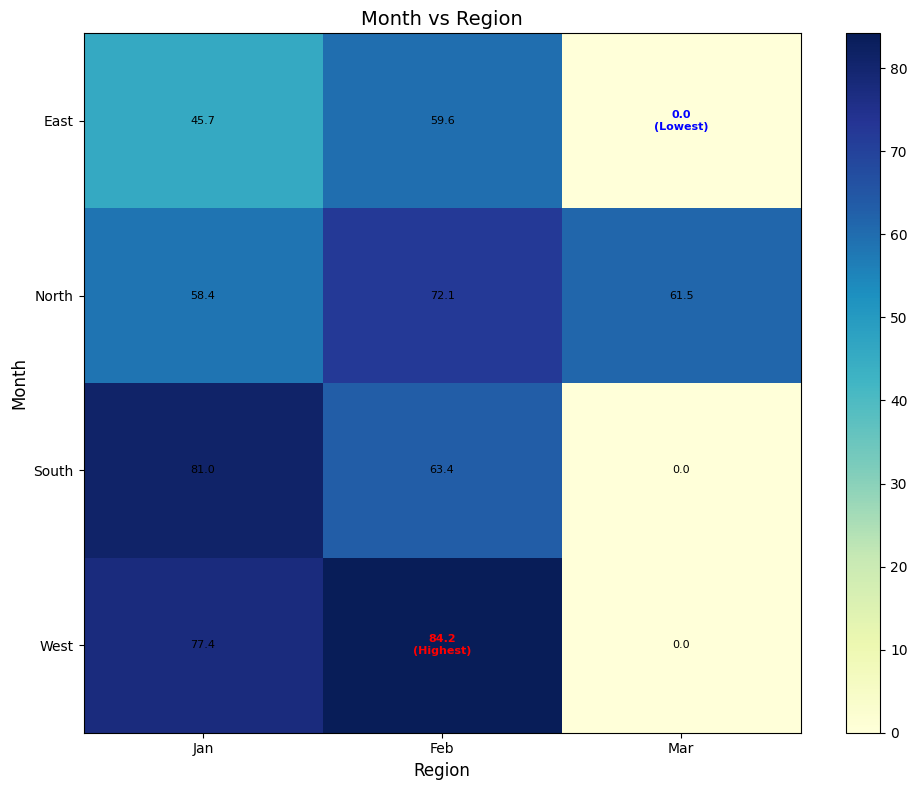

In [ ]:
#Write your code here

# Calculate average rainfall by month and region
avg_month_region = month_region['Rainfall_mm'].mean()
avg_month_region.fillna(0, inplace=True)

# Create pivot table for heatmap
heatmap_data = avg_month_region.unstack()

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')

# Set ticks and labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)

# Find highest and lowest values positions
max_val = heatmap_data.max().max()
min_val = heatmap_data.min().min()
max_pos = np.where(heatmap_data == max_val)
min_pos = np.where(heatmap_data == min_val)

# Add text annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        
        # Check if this is the highest or lowest point
        if i == max_pos[0][0] and j == max_pos[1][0]:
            text = ax.text(j, i, f'{value:.1f}\n(Highest)',
                          ha="center", va="center", color="red", fontsize=8, weight='bold')
        elif i == min_pos[0][0] and j == min_pos[1][0]:
            text = ax.text(j, i, f'{value:.1f}\n(Lowest)',
                          ha="center", va="center", color="blue", fontsize=8, weight='bold')
        else:
            text = ax.text(j, i, f'{value:.1f}',
                          ha="center", va="center", color="black", fontsize=8)

# Customize plot
ax.set_title("Month vs Region", fontsize=14)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Month", fontsize=12)

plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


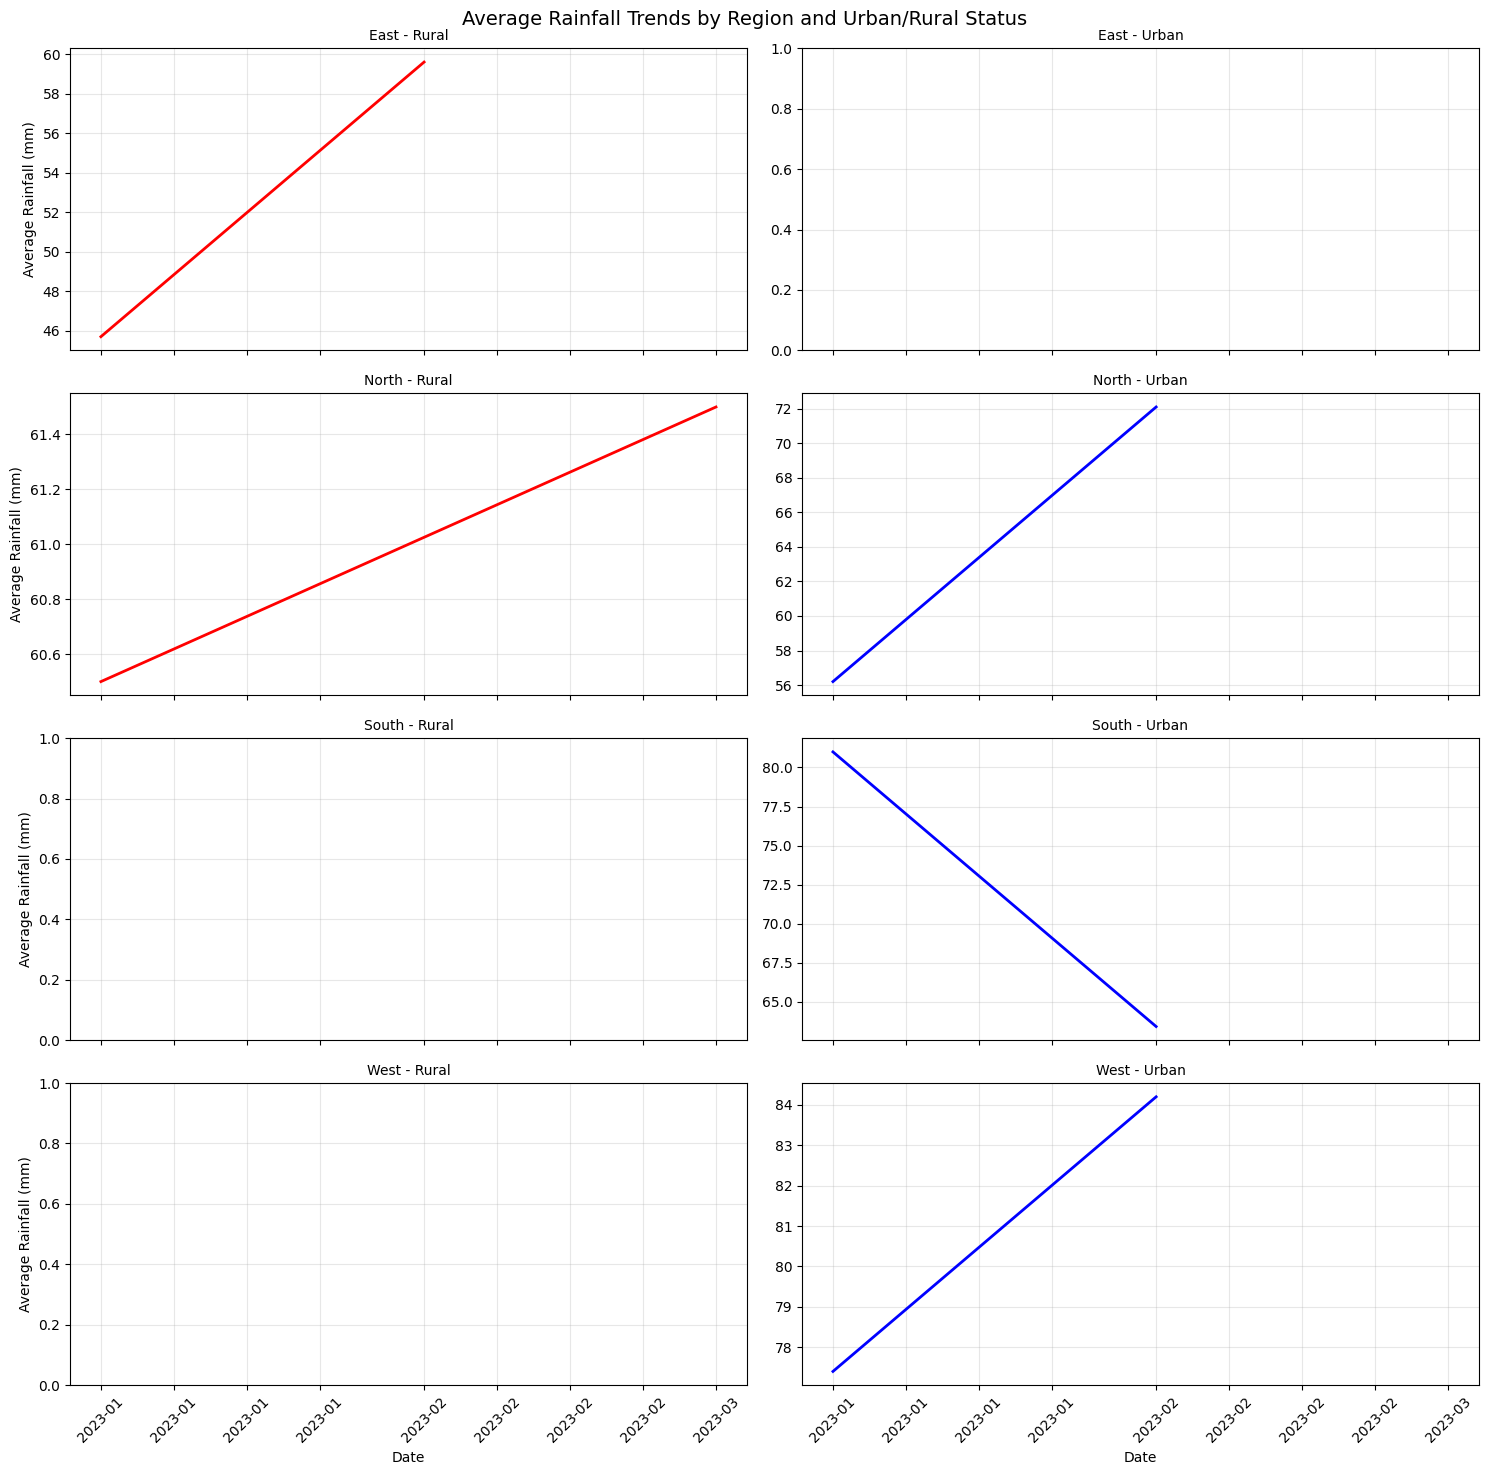

In [ ]:
#Write your code here
import matplotlib.dates as mdates

# Create a 'Date' column by combining 'Year' and 'Month'
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
rain['Month_Num'] = rain['Month'].map(month_mapping)
rain['Date'] = pd.to_datetime(rain['Year'].astype(str) + '-' + rain['Month_Num'].astype(str) + '-01')

# Group by Date, Region, and UrbanRural and calculate the mean rainfall
df_grouped = rain.groupby(['Date', 'Region', 'UrbanRural'])['Rainfall_mm'].mean().reset_index()

# Get unique regions and urban/rural categories
regions = df_grouped['Region'].unique()
urban_rural = df_grouped['UrbanRural'].unique()
colors = {'Urban': 'blue', 'Rural': 'red'}  # Define colors for Urban/Rural

# Create subplots grid
n_regions = len(regions)
n_urban_rural = len(urban_rural)
fig, axes = plt.subplots(n_regions, n_urban_rural, figsize=(15, 15), sharex=True)

# Ensure axes is 2D array for consistent indexing
if n_regions == 1:
    axes = axes.reshape(1, -1)
if n_urban_rural == 1:
    axes = axes.reshape(-1, 1)

# Plot data for each region and urban/rural combination
for i, region in enumerate(regions):
    for j, ur in enumerate(urban_rural):
        ax = axes[i, j]
        
        # Filter data for current region and urban/rural category
        subset = df_grouped[(df_grouped['Region'] == region) & 
                           (df_grouped['UrbanRural'] == ur)]
        
        if not subset.empty:
            ax.plot(subset['Date'], subset['Rainfall_mm'], 
                   color=colors[ur], linewidth=2, label=ur)
        
        # Set subplot title
        ax.set_title(f'{region} - {ur}', fontsize=10)
        
        # Format x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Set y-label for leftmost subplots
        if j == 0:
            ax.set_ylabel('Average Rainfall (mm)', fontsize=10)
        
        # Set x-label for bottom subplots
        if i == n_regions - 1:
            ax.set_xlabel('Date', fontsize=10)

# Add main title
fig.suptitle('Average Rainfall Trends by Region and Urban/Rural Status', fontsize=14, y=0.98)

plt.tight_layout()
plt.show()

# Save the plot
plt.savefig('rainfall_trends_relplot_labeled_date.png')
plt.close()


3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here

Based on the visualizations of average rainfall trends by region and urban/rural status for January and February 2023, there is a noticeable regional differences, with the South continually receiving more average rainfall than the North, East, and West. The impact of urban versus rural status on rainfall varies by region. Urban areas in the South received more rainfall than rural areas, while the East saw the opposite pattern, and the North had similar rainfall levels across urban and rural areas. In the West, urban areas received more rainfall in January, but both urban and rural areas experienced considerable decreases by February, demonstrating various short-term trends among regions over this two-month period.